In [33]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [34]:
class State(TypedDict):
    year : int
    leapyear_verdict : str

In [35]:
def get_year(St: State) -> State:
    year = input("year: ")
    year = int(year)
    St['year'] = year
    return St

def is_leap_year(St: State) -> str:
    year = St['year']
    if year % 400:
        return 'leap_year'
    elif year % 100:
        return 'not_leap_year'
    elif year % 4:
        return 'leap_year'
    else:
        return 'not_leap_year'

def leap_year(St: State) -> State:

    year = St['year']
    St['leapyear_verdict'] = f"{year} is a leap Year"

    return St

def not_leap_year(St: State) -> State:

    year = St['year']
    St['leapyear_verdict'] = f"{year} is _NOT_ a leap Year"

    return St

In [36]:
graph = StateGraph(State)

graph.add_node("INPUT", get_year)
graph.add_node("LEAP", leap_year)
graph.add_node("NOT_LEAP", not_leap_year)

graph.add_edge(START, 'INPUT')
graph.add_conditional_edges('INPUT', is_leap_year, {'leap_year': 'LEAP', 'not_leap_year': 'NOT_LEAP'})
graph.add_edge('LEAP', END)
graph.add_edge('NOT_LEAP', END)

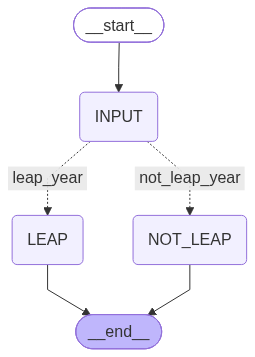

In [37]:
graph.compile()

In [38]:
agent = graph.compile()

In [39]:
intial_state = {}
final_state = agent.invoke(intial_state)

In [40]:
print(final_state)

{'year': 2020, 'leapyear_verdict': '2020 is a leap Year'}


In [41]:
print(final_state['leapyear_verdict'])

2020 is a leap Year
